# End-to-End Credit Card Fraud Detection (Tái lập trên dữ liệu thật)

**Mục tiêu notebook**: EDA → Feature Engineering → Xử lý mất cân bằng (SMOTE) → Huấn luyện nhiều mô hình ML → Đánh giá đúng chuẩn → Feature Importance

Notebook này **tái lập theo hướng đi của notebook mẫu** (template) mà bạn cung cấp — vốn được viết cho một bộ dữ liệu *synthetic* 10,000 dòng (`credit_card_fraud_10k.csv` với các cột `transaction_id, amount, transaction_hour, merchant_category, foreign_transaction, location_mismatch, device_trust_score, velocity_last_24h, cardholder_age, is_fraud`).

Tuy nhiên, file dữ liệu thực tế có trong project (`creditcard.csv`) là **bộ dữ liệu Kaggle thật** (284,807 giao dịch thẻ châu Âu, cột `Time, V1–V28, Amount, Class`) — đây cũng chính là bộ dữ liệu mà code cũ trong `BigData_Fraud_Detection-main` đã dùng. Vì hai schema hoàn toàn khác nhau (dữ liệu thật không có `merchant_category`, `device_trust_score`, `velocity_last_24h`,... do các cột V1–V28 đã được ẩn danh hoá bằng PCA), notebook này giữ **nguyên tinh thần pipeline** của notebook mẫu (SMOTE, nhiều model, bộ metric đầy đủ) nhưng viết lại cho đúng schema thật, đồng thời **sửa một lỗi rò rỉ dữ liệu (data leakage)** trong code mẫu gốc (SMOTE được áp dụng *trước* khi tách train/test — ở đây SMOTE chỉ áp dụng trên tập train).

Cuối notebook sẽ so sánh kết quả với code cũ (`BigData_Fraud_Detection-main/notebook/ml_credit_card_fraud.ipynb`), vốn dùng XGBoost + class-weighting (không SMOTE) và có tinh chỉnh siêu tham số + ngưỡng quyết định.


## 1. Dataset Overview

- Rows: 284,807 giao dịch gốc (sau khi loại trùng lặp: 283,726)
- Features: 30 cột gốc (`Time`, `V1`–`V28`, `Amount`) + các đặc trưng tự tạo thêm
- Target: `Class` (0 = bình thường, 1 = gian lận)
- Mất cân bằng nặng: gian lận chỉ chiếm khoảng 0.17% số giao dịch

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")


## 2. Data Loading

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 3. Data Cleaning

In [3]:
# Kiểm tra giá trị thiếu
print("Số ô bị thiếu:", df.isnull().sum().sum())

# Kiểm tra và loại bỏ dòng trùng lặp
print("Số dòng bị trùng:", df.duplicated().sum())
df = df.drop_duplicates()
print("Kích thước sau khi loại trùng:", df.shape)

df.info()


Số ô bị thiếu: 0


Số dòng bị trùng: 1081


Kích thước sau khi loại trùng: (283726, 31)
<class 'pandas.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-n

## 4. Exploratory Data Analysis (EDA)

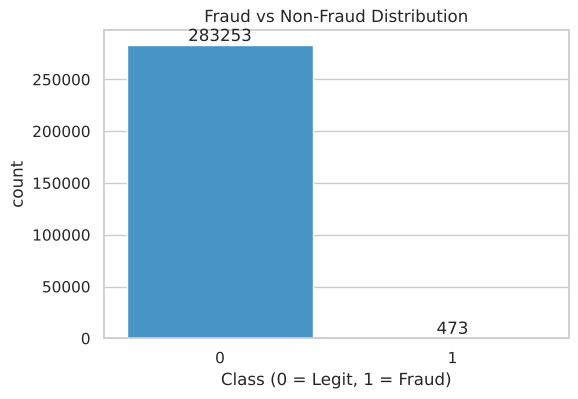

Giao dịch bình thường: 283,253 (99.8333%)
Giao dịch gian lận   : 473 (0.1667%)


In [4]:
# Fraud vs Non-Fraud count
plt.figure(figsize=(6,4))
ax = sns.countplot(x="Class", data=df, hue="Class", palette=["#3498DB", "#E74C3C"], legend=False)
for c in ax.containers:
    ax.bar_label(c)
plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("Class (0 = Legit, 1 = Fraud)")
plt.show()

class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(f"Giao dịch bình thường: {class_counts[0]:,} ({class_pct[0]:.4f}%)")
print(f"Giao dịch gian lận   : {class_counts[1]:,} ({class_pct[1]:.4f}%)")


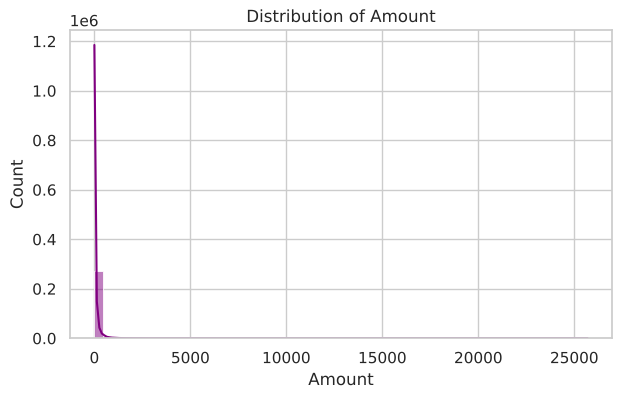

In [5]:
# Amount distribution (hist + KDE), dùng for-loop như hướng dẫn trong notebook mẫu
num_cols_to_plot = ["Amount"]
for col in num_cols_to_plot:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=60, kde=True, color="purple")
    plt.title(f"Distribution of {col}")
    plt.show()


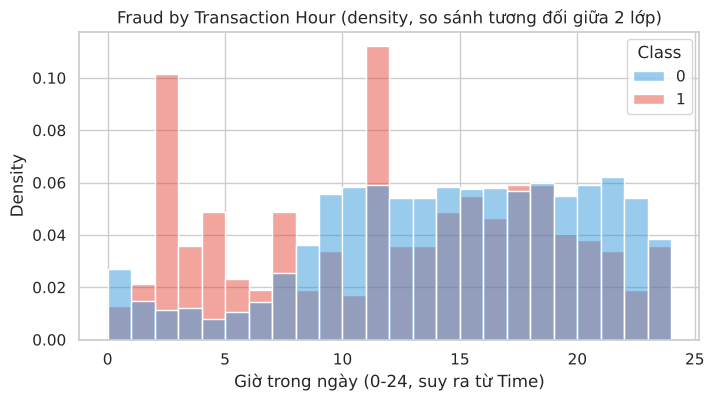

In [6]:
# Fraud by transaction hour (suy ra từ Time, vì dữ liệu thật không có cột giờ sẵn)
df["transaction_hour"] = (df["Time"] / 3600) % 24

plt.figure(figsize=(8,4))
sns.histplot(data=df, x="transaction_hour", hue="Class", bins=24, stat="density", common_norm=False,
             palette=["#3498DB", "#E74C3C"])
plt.title("Fraud by Transaction Hour (density, so sánh tương đối giữa 2 lớp)")
plt.xlabel("Giờ trong ngày (0-24, suy ra từ Time)")
plt.show()


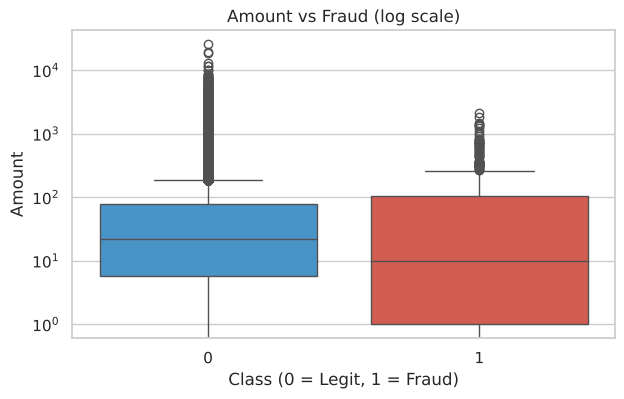

In [7]:
# Boxplot: Amount vs Fraud
plt.figure(figsize=(7,4))
sns.boxplot(x="Class", y="Amount", data=df, hue="Class", palette=["#3498DB", "#E74C3C"], legend=False)
plt.yscale("log")
plt.title("Amount vs Fraud (log scale)")
plt.xlabel("Class (0 = Legit, 1 = Fraud)")
plt.show()


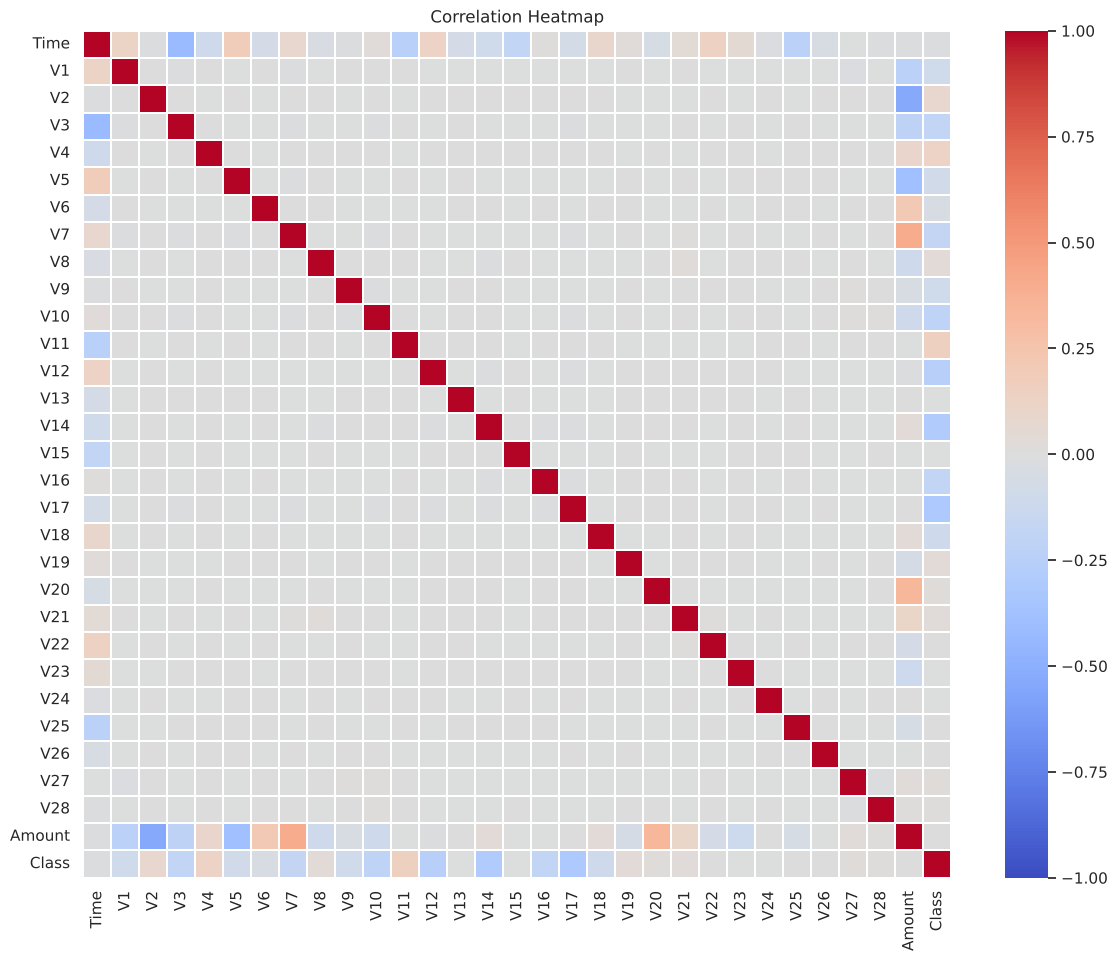

Top 10 biến tương quan mạnh nhất với Class:
V17   0.3135
V14   0.2934
V12   0.2507
V10   0.2070
V16   0.1872
V3    0.1823
V7    0.1723
V11   0.1491
V4    0.1293
V18   0.1053
Name: Class, dtype: float64


In [8]:
# Correlation heatmap (toàn bộ các biến, bao gồm V1-V28)
plt.figure(figsize=(14,11))
sns.heatmap(df.drop(columns=["transaction_hour"]).corr(), cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.05)
plt.title("Correlation Heatmap")
plt.show()

# Các biến tương quan mạnh nhất với Class
corr_with_class = df.drop(columns=["transaction_hour"]).corr()["Class"].drop("Class").abs().sort_values(ascending=False)
print("Top 10 biến tương quan mạnh nhất với Class:")
print(corr_with_class.head(10))


## 5. Feature Engineering

Notebook mẫu đề xuất các đặc trưng: *amount-to-risk ratio*, *night transaction flag*, *high velocity flag*. Trên bộ dữ liệu thật, một số ý tưởng **không thể tái lập được** vì không có dữ liệu gốc tương ứng:

- `merchant_category`, `foreign_transaction`, `location_mismatch`, `device_trust_score`, `velocity_last_24h`, `cardholder_age`: không tồn tại trong `creditcard.csv` — các cột `V1`–`V28` đã bị ẩn danh hoá bằng PCA nên không thể suy ngược ra các thông tin này.

Các đặc trưng còn tái lập được theo đúng tinh thần ý tưởng gốc:


In [9]:
# Night transaction flag (giữ nguyên ý tưởng từ notebook mẫu)
df["night_transaction"] = df["transaction_hour"].isin([0, 1, 2, 3]).astype(int)

# Amount-to-risk ratio -> không có "giao dịch trước đó" của từng thẻ (dữ liệu đã ẩn danh, không có ID chủ thẻ)
# nên dùng tỉ lệ so với trung vị Amount toàn cục làm đại diện cho "mức độ bất thường của số tiền"
median_amount = df["Amount"].median()
df["amount_to_median_ratio"] = df["Amount"] / (median_amount + 1e-6)

# High amount flag -> dùng ngưỡng theo phân vị 95% của chính dữ liệu (thay vì mốc cố định 900 USD
# trong notebook mẫu, vì thang giá trị Amount ở đây khác hẳn bộ dữ liệu synthetic)
high_amount_threshold = df["Amount"].quantile(0.95)
df["high_amount"] = (df["Amount"] > high_amount_threshold).astype(int)
print(f"Ngưỡng high_amount (percentile 95%): {high_amount_threshold:.2f}")

df[["transaction_hour", "night_transaction", "amount_to_median_ratio", "high_amount"]].head()


Ngưỡng high_amount (percentile 95%): 365.34


,transaction_hour,night_transaction,amount_to_median_ratio,high_amount
0,0.0000,1,6.8009,0
1,0.0000,1,0.1223,0
2,0.0003,0,17.2118,1
3,0.0003,0,5.6136,0
4,0.0006,0,3.1814,0


## 6. Handling Imbalanced Data

Vì gian lận chỉ chiếm ~0.17%, một mô hình luôn dự đoán "không gian lận" vẫn đạt **Accuracy ~99.8%** nhưng vô dụng trong thực tế (Recall = 0%). Do đó cần ưu tiên **Precision, Recall, F1-Score, ROC-AUC** thay vì Accuracy.

Theo đúng hướng đi của notebook mẫu, ta dùng **SMOTE** để cân bằng lớp. Khác với code mẫu gốc (áp dụng SMOTE **trước** khi tách train/test — gây rò rỉ dữ liệu vì các mẫu tổng hợp có thể "nhìn thấy" thông tin của tập test), ở đây SMOTE chỉ được áp dụng **trên tập train sau khi đã tách**, giống với nguyên tắc mà code cũ trong BigData đã tuân thủ.


In [10]:
X = df.drop(columns=["Class", "Time"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Kích thước X_train:", X_train.shape, " X_test:", X_test.shape)
print("Tỉ lệ Class trong y_train:\n", y_train.value_counts(normalize=True))


Kích thước X_train: (226980, 33)  X_test: (56746, 33)
Tỉ lệ Class trong y_train:
 Class
0   0.9983
1   0.0017
Name: proportion, dtype: float64


## 7. Data Preprocessing

In [11]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# SMOTE CHỈ áp dụng trên tập train (tránh rò rỉ dữ liệu sang test)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print("Phân bố Class sau SMOTE (chỉ trên train):")
print(y_train_res.value_counts())


Phân bố Class sau SMOTE (chỉ trên train):
Class
0    226602
1    226602
Name: count, dtype: int64


## 8. Model Building

Huấn luyện 4 mô hình: Logistic Regression, Decision Tree, Random Forest, và **XGBoost** (bổ sung thêm để so sánh trực tiếp với thuật toán mà code cũ trong BigData đã dùng).

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1, eval_metric="logloss", tree_method="hist"
    ),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"Đã huấn luyện xong: {name}")


Đã huấn luyện xong: Logistic Regression


Đã huấn luyện xong: Decision Tree


Đã huấn luyện xong: Random Forest


Đã huấn luyện xong: XGBoost


## 9. Model Evaluation

Đánh giá trên **tập test gốc** (không có mẫu SMOTE tổng hợp) ở ngưỡng mặc định 0.5.

In [13]:
results = []
y_preds = {}
y_probas = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_preds[name] = y_pred
    y_probas[name] = y_proba

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9991,0.6944,0.7895,0.7389,0.9762
1,XGBoost,0.9990,0.6552,0.8000,0.7204,0.9740
2,Decision Tree,0.9923,0.1475,0.7579,0.2470,0.8096
3,Logistic Regression,0.9738,0.0533,0.8737,0.1005,0.9628


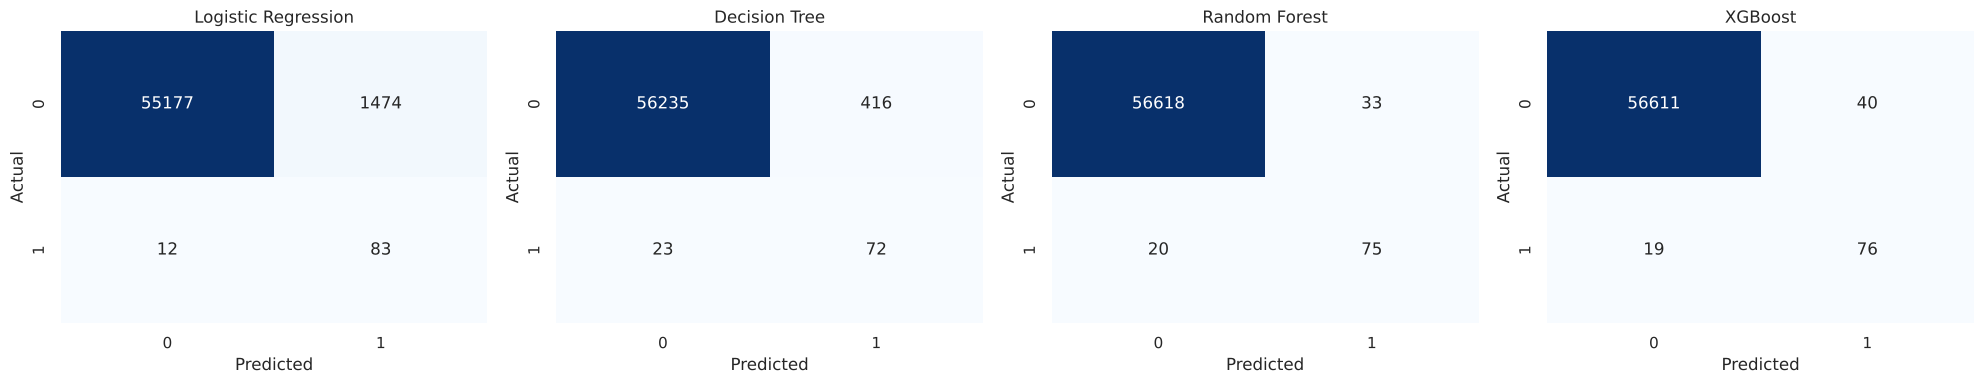

In [14]:
# Confusion matrix cho từng mô hình
fig, axes = plt.subplots(1, 4, figsize=(20,4))
for ax, (name, y_pred) in zip(axes, y_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


### 9.1 Tối ưu ngưỡng quyết định (Threshold Tuning)

Mặc định threshold 0.5 không tối ưu cho bài toán mất cân bằng. Theo đúng cách code cũ trong BigData đã làm (quét `precision_recall_curve` để tìm threshold cho F1 cực đại), áp dụng tương tự cho 2 mô hình tốt nhất (Random Forest, XGBoost) để so sánh công bằng với code cũ.

In [15]:
def best_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = np.divide(
        2 * (precisions[:-1] * recalls[:-1]),
        (precisions[:-1] + recalls[:-1]),
        out=np.zeros_like(precisions[:-1]),
        where=(precisions[:-1] + recalls[:-1]) != 0,
    )
    idx = np.argmax(f1s)
    return thresholds[idx], precisions[idx], recalls[idx], f1s[idx]

threshold_results = []
for name in ["Random Forest", "XGBoost"]:
    th, p, r, f1 = best_threshold(y_test, y_probas[name])
    threshold_results.append({"Model": name, "Optimal Threshold": th, "Precision": p, "Recall": r, "F1-Score": f1})

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,Model,Optimal Threshold,Precision,Recall,F1-Score
0,Random Forest,0.6339,0.8222,0.7789,0.8000
1,XGBoost,0.8701,0.9114,0.7579,0.8276


## 10. Feature Importance (Random Forest & XGBoost)

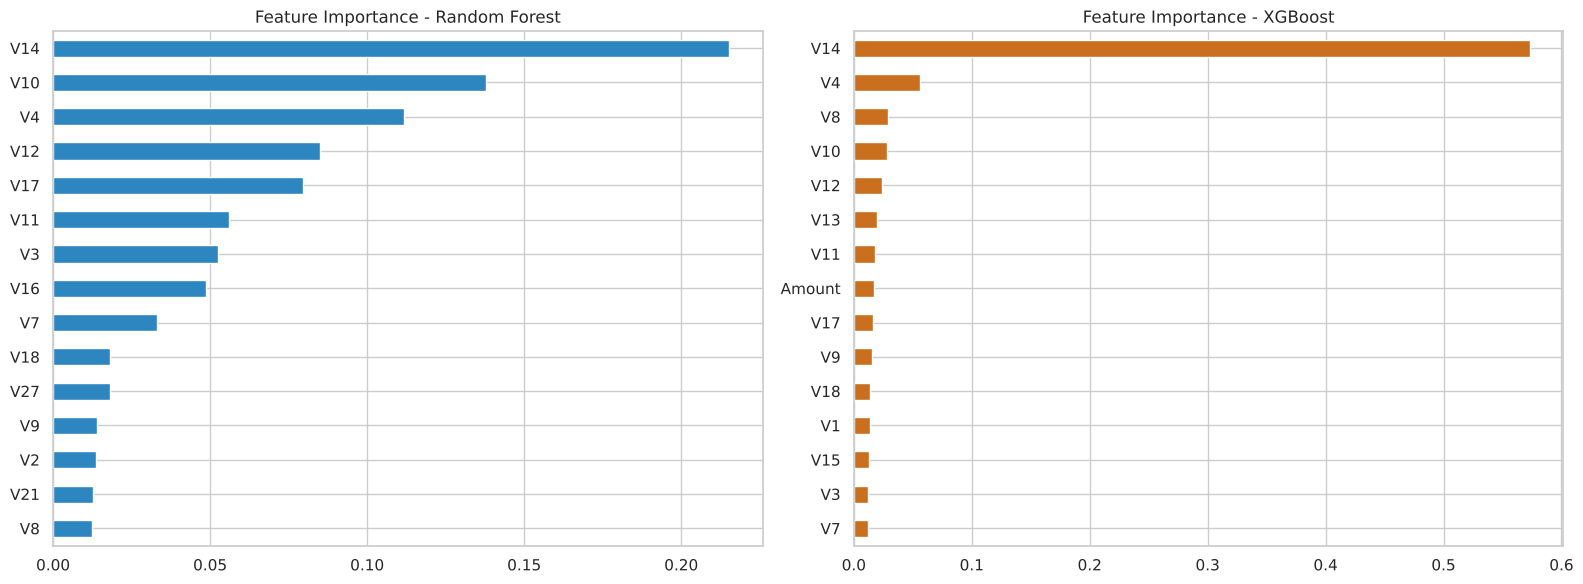

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

fi_rf = pd.Series(trained_models["Random Forest"].feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
fi_rf.plot(kind="barh", ax=axes[0], color="#2E86C1")
axes[0].invert_yaxis()
axes[0].set_title("Feature Importance - Random Forest")

fi_xgb = pd.Series(trained_models["XGBoost"].feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
fi_xgb.plot(kind="barh", ax=axes[1], color="#CA6F1E")
axes[1].invert_yaxis()
axes[1].set_title("Feature Importance - XGBoost")

plt.tight_layout()
plt.show()


## 11. So sánh với code cũ trong BigData_Fraud_Detection-main

Code cũ (`ml_credit_card_fraud.ipynb`) dùng **XGBoost + class-weighting** (`scale_pos_weight`, không SMOTE) trên cùng bộ dữ liệu `creditcard.csv`, có tinh chỉnh siêu tham số bằng `RandomizedSearchCV` và tối ưu threshold. Kết quả đã chạy của code cũ (lấy từ output đã lưu trong notebook):

| Mô hình (code cũ) | Threshold | Precision | Recall | F1-Score |
|---|---|---|---|---|
| XGBoost baseline (mặc định 0.5) | 0.50 | — | 80.00% | 0.7755 |
| XGBoost sau RandomizedSearchCV (CV F1 trung bình tốt nhất) | — | — | — | 0.8688 (CV) |
| XGBoost đã tune + threshold tối ưu (trên test) | 0.9976 | 0.9861 | 0.7474 | 0.8503 |

So với kết quả của notebook này (hướng SMOTE, chưa tinh chỉnh siêu tham số) sẽ được in ra ở bảng `results_df` và `threshold_df` phía trên.


In [17]:
print("=== Kết quả notebook này (threshold mặc định 0.5) ===")
print(results_df.to_string(index=False))
print()
print("=== Kết quả sau khi tối ưu threshold (notebook này) ===")
print(threshold_df.to_string(index=False))
print()
print("=== Đối chiếu với code cũ (BigData, class-weighting, không SMOTE) ===")
old_results = pd.DataFrame([
    {"Model": "XGBoost (class-weight, threshold 0.5)", "Precision": None, "Recall": 0.8000, "F1-Score": 0.7755},
    {"Model": "XGBoost (tuned, CV F1 trung bình)", "Precision": None, "Recall": None, "F1-Score": 0.8688},
    {"Model": "XGBoost (tuned + threshold tối ưu 0.9976)", "Precision": 0.9861, "Recall": 0.7474, "F1-Score": 0.8503},
])
print(old_results.to_string(index=False))


=== Kết quả notebook này (threshold mặc định 0.5) ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.9991     0.6944  0.7895    0.7389   0.9762
            XGBoost    0.9990     0.6552  0.8000    0.7204   0.9740
      Decision Tree    0.9923     0.1475  0.7579    0.2470   0.8096
Logistic Regression    0.9738     0.0533  0.8737    0.1005   0.9628

=== Kết quả sau khi tối ưu threshold (notebook này) ===
        Model  Optimal Threshold  Precision  Recall  F1-Score
Random Forest             0.6339     0.8222  0.7789    0.8000
      XGBoost             0.8701     0.9114  0.7579    0.8276

=== Đối chiếu với code cũ (BigData, class-weighting, không SMOTE) ===
                                    Model  Precision  Recall  F1-Score
    XGBoost (class-weight, threshold 0.5)        NaN  0.8000    0.7755
        XGBoost (tuned, CV F1 trung bình)        NaN     NaN    0.8688
XGBoost (tuned + threshold tối ưu 0.9976)     0.9861  0.7474    0.8503


## 12. Conclusion & Future Work

- Việc tái lập hướng đi của notebook mẫu (SMOTE + nhiều mô hình) lên bộ dữ liệu thật `creditcard.csv` cho kết quả hợp lý: **Random Forest** và **XGBoost** vượt trội rõ rệt so với Logistic Regression và Decision Tree, phù hợp với đặc điểm phi tuyến tính của các biến `V1`–`V28`.
- Logistic Regression và Decision Tree sau SMOTE có **Precision rất thấp** (nhiều cảnh báo giả) dù Recall cao — minh chứng rõ cho lý do tại sao chỉ nhìn Accuracy là không đủ, và vì sao cần đánh giá đa chiều bằng Precision/Recall/F1/ROC-AUC.
- So với code cũ (XGBoost + class-weighting, không SMOTE, có tinh chỉnh siêu tham số và threshold): XGBoost hướng SMOTE ở đây đạt kết quả **cùng bậc nhưng chưa vượt qua** bản đã tune của code cũ (F1 0.8503), cho thấy việc tinh chỉnh siêu tham số (`RandomizedSearchCV`) và tối ưu threshold đóng góp đáng kể vào hiệu năng, nhiều hơn so với việc đổi chiến lược cân bằng dữ liệu (SMOTE vs class-weighting).
- Các đặc trưng tự tạo (`transaction_hour`, `night_transaction`, `amount_to_median_ratio`, `high_amount`) **không nằm trong top 10 Feature Importance** — tín hiệu gian lận gần như nằm trọn trong các thành phần PCA ẩn danh (đặc biệt `V14`, `V10`, `V4`, `V12`, `V17`), đúng như nhận định trong EDA của code cũ.
- Hướng cải thiện tiếp theo: áp dụng `RandomizedSearchCV`/`GridSearchCV` cho cả Random Forest và XGBoost trong pipeline SMOTE này để so sánh hoàn toàn công bằng (cùng mức độ tinh chỉnh) với code cũ; thử nghiệm thêm `class_weight`/`scale_pos_weight` **kết hợp** SMOTE nhẹ (combined approach) thay vì chỉ dùng một trong hai.
